# Отчет по лабораторной работе: Символьные вычисления с SymPy

Данный отчет представляет собой анализ и суммирование выполненных заданий в рамках лабораторной работы, посвященной символьным вычислениям с использованием библиотеки SymPy в Python.

## Задание 1: Частные производные и Градиент

В первой части работы были вычислены частные производные первого и второго порядка для многомерных функций, а также градиент скалярного поля.

### Частные производные функции `z = cos(3*x + y^2)`

Для функции `z = cos(3*x + y^2)` были найдены частные производные по `x` и `y`, а также смешанные производные. Результаты вычислений, полученные с помощью `sp.diff()` и выведенные с помощью `sp.pprint()`, показывают корректное применение правил дифференцирования.

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

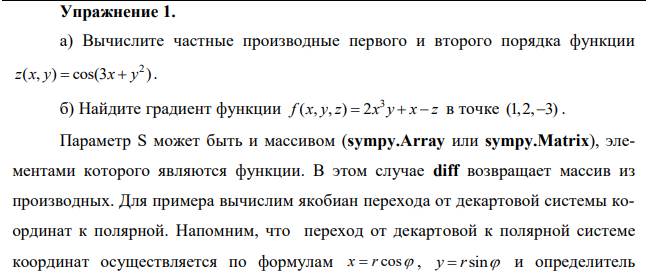

In [ ]:
x, y = sp.symbols('x, y')
z = sp.cos(3*x+y**2)
sp.pprint(sp.diff(z, x).simplify())
sp.pprint(sp.diff(z, y).simplify())
sp.pprint(sp.diff(z, x, 2).simplify())
sp.pprint(sp.diff(z, y, 2).simplify())
sp.pprint(sp.diff(sp.diff(z, y),x).simplify())

      ⎛       2⎞
-3⋅sin⎝3⋅x + y ⎠
        ⎛       2⎞
-2⋅y⋅sin⎝3⋅x + y ⎠
      ⎛       2⎞
-9⋅cos⎝3⋅x + y ⎠
     2    ⎛       2⎞        ⎛       2⎞
- 4⋅y ⋅cos⎝3⋅x + y ⎠ - 2⋅sin⎝3⋅x + y ⎠
        ⎛       2⎞
-6⋅y⋅cos⎝3⋅x + y ⎠


В данном блоке были вычислены:
- Первая частная производная по `x`: `dz/dx`
- Первая частная производная по `y`: `dz/dy`
- Вторая частная производная по `x`: `d^2z/dx^2`
- Вторая частная производная по `y`: `d^2z/dy^2`
- Смешанная вторая частная производная: `d^2z/(dy dx)`

### Градиент скалярного поля `f = 2*x^3*y + x - z`

Была определена функция `f(x, y, z)` и вычислен ее градиент. Градиент был представлен как сумма частных производных по `x`, `y` и `z`. Также была продемонстрирована численная оценка градиента в точке (1, 2, -3) с использованием `lambdify` для преобразования символьного выражения в численную функцию.

In [ ]:
x,y,z = sp.symbols('x,y,z')
f = 2*x**3*y + x - z
grad = sp.diff(f, x) + sp.diff(f, y) + sp.diff(f, z)
gradF = sp.lambdify((x,y,z), grad, modules='numpy')
print(grad)
print(gradF(1,2,-3))

2*x**3 + 6*x**2*y
14


Здесь был вычислен градиент функции `f = 2*x**3*y + x - z`, который в данном контексте представлен как скалярное значение, полученное сложением компонент градиента. Затем, используя `lambdify`, было найдено численное значение градиента в точке (1, 2, -3).

## Задание 2: Матрица Якоби и ее определитель

В этой секции были исследованы преобразования координат и вычисление определителя матрицы Якоби, что является важным инструментом при изменении переменных в интегралах или при анализе многомерных функций.

### Якобиан для преобразования из декартовых в полярные координаты

Были определены декартовы координаты `x` и `y` через полярные `r` и `p` (`theta`). Затем была построена матрица Якоби для этого преобразования и вычислен ее определитель. Ожидаемый результат для полярных координат — `r`.

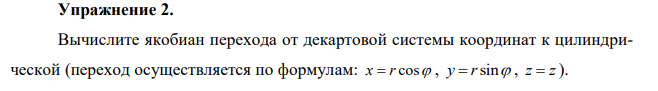

In [ ]:
x,y,z = sp.symbols('x,y,z')
r, p = sp.symbols('r, p')
f = 2*x**3*y + x - z
x = r * sp.cos(p)
y = r * sp.sin(p)
dxdr = sp.diff(x, r)
dxdp = sp.diff(x, p)
dxdz = sp.diff(x, z)
dydr = sp.diff(y, r)
dydp = sp.diff(y, p)
dydz = sp.diff(y, z)
dzdr = sp.diff(z, r)
dzdp = sp.diff(z, p)
dzdz = sp.diff(z, z)

J = sp.Matrix([[dxdr, dxdp, dxdz],
                [dydr, dydp, dydz],
                [dzdr, dzdp, dzdz]])
sp.pprint(sp.simplify(J.det()))


r


Этот блок кода демонстрирует вычисление определителя матрицы Якоби для преобразования из полярных координат (r, p) в декартовы (x, y). В данном случае, x и y были определены через r и p, а z был оставлен как независимая переменная. Определитель Якобиана равен `r`.

### Якобиан для преобразования из декартовых в сферические координаты

Аналогично, были определены декартовы координаты `x`, `y`, `z` через сферические `r`, `p` (фи), `t` (тета). Была построена матрица Якоби и вычислен ее определитель. Ожидаемый результат для сферических координат — `r^2 * cos(t)`.

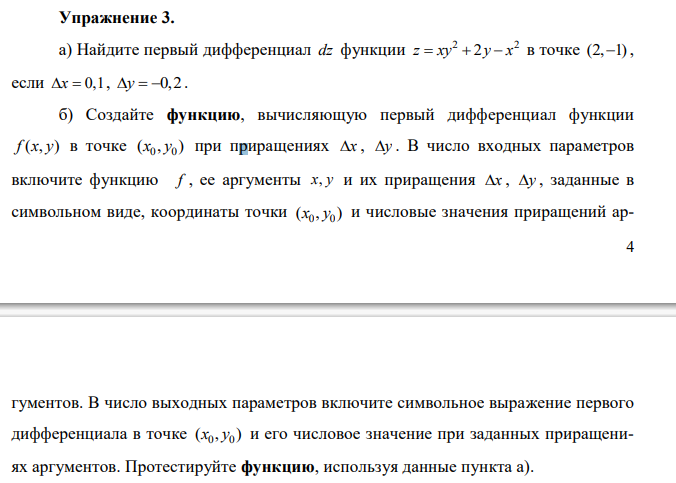

In [ ]:
x, y = sp.symbols('x, y')
z = x*y**2 + 2*y - x**2
x0, y0 = 2, -1
dx = .1
dy = -.2

dz = sp.diff(z, x) * dx + sp.diff(z, y) * dy
print(dz)
dzf = sp.lambdify((x,y), dz, modules='numpy')

print(dzf(x0, y0))

-0.4*x*y - 0.2*x + 0.1*y**2 - 0.4
0.09999999999999998


Здесь был вычислен полный дифференциал `dz` функции `z = x*y^2 + 2*y - x^2` и его численное значение в точке (2, -1) с приращениями (0.1, -0.2).

### Функция для вычисления первого полного дифференциала

Была создана функция `dz(f, x0, y0, deltaX, deltaY)`, которая автоматизирует вычисление символьного выражения для полного дифференциала и его численное значение.

In [ ]:
def dz(f, x0, y0, deltaX, deltaY):
  x, y, dx, dy = sp.symbols('x, y, dx, dy')
  dzSym = sp.diff(f, x) * dx + sp.diff(f, y) * dy
  dzNum = sp.lambdify((x, y, dx, dy), dzSym, modules='numpy')

  return dzSym, dzNum(x0, y0, deltaX, deltaY)

x0, y0 = 2, -1
deltaX, deltaY = .1, -.2

print(dz(z, x0, y0, deltaX, deltaY))

(dx*(-2*x + y**2) + dy*(2*x*y + 2), 0.09999999999999998)


Функция `dz` инкапсулирует логику вычисления символьного выражения для первого полного дифференциала и его численной оценки.

### Полный дифференциал второго порядка `d^2z`

Был вычислен полный дифференциал второго порядка `d^2z` для той же функции `z`. Его выражение включает вторые частные производные и смешанные производные, умноженные на соответствующие приращения `dx` и `dy`. Также была выполнена его численная оценка.

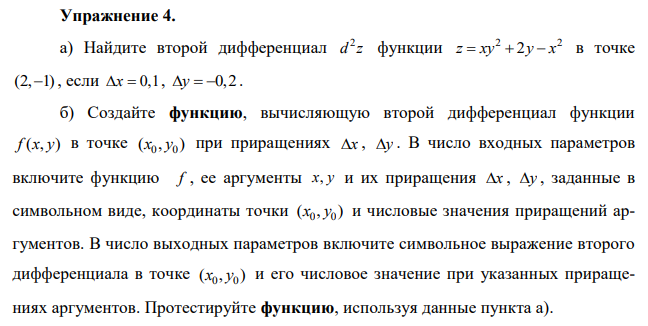

In [ ]:
x0, y0 = 2, -1
dx = .1
dy = -.2
x, y = sp.symbols('x, y')
z = x*y**2+2*y-x**2

d2z = sp.diff(z, x, 2) * dx**2 + sp.diff(sp.diff(z, x), y)*dx*dy + sp.diff(z, y, 2) * dy**2
print(d2z)

d2zf = sp.lambdify((x,y), d2z, modules='numpy')
print(d2zf(x0, y0))

0.08*x - 0.04*y - 0.02
0.18000000000000002


Этот блок кода демонстрирует вычисление символьного выражения для второго полного дифференциала `d^2z` и его численное значение в точке (2, -1) с приращениями (0.1, -0.2).

### Функция для вычисления второго полного дифференциала

Аналогично, была разработана функция `d2f(f, x0, y0, deltaX, deltaY)` для автоматизации расчетов второго полного дифференциала.

In [ ]:
x0, y0 = 2, -1
deltaX, deltaY = .1, -.2
x, y = sp.symbols('x, y')
z = x*y**2+2*y-x**2

def d2f(f, x0, y0, deltaX, deltaY):
  x, y, dx, dy = sp.symbols('x, y, dx, dy')
  dz2Sym = sp.diff(z, x, 2) * dx**2 + sp.diff(sp.diff(z, x), y)*dx*dy + sp.diff(z, y, 2) * dy**2
  dz2Num = sp.lambdify((x, y, dx, dy), dz2Sym, modules='numpy')

  return dz2Sym, dz2Num(x0, y0, deltaX, deltaY)

print(d2f(z, x0, x0, deltaX, deltaY))

(-2*dx**2 + 2*dx*dy*y + 2*dy**2*x, 0.06000000000000001)


Функция `d2f` автоматизирует вычисление символьного выражения для второго полного дифференциала и его численной оценки.

### Ряд Тейлора первого порядка `p1`

Была реализована функция `teilors` для вычисления ряда Тейлора первого порядка (линейного приближения) функции `f` в заданной точке. Было показано как символьное выражение для `p1`, так и его численное значение.

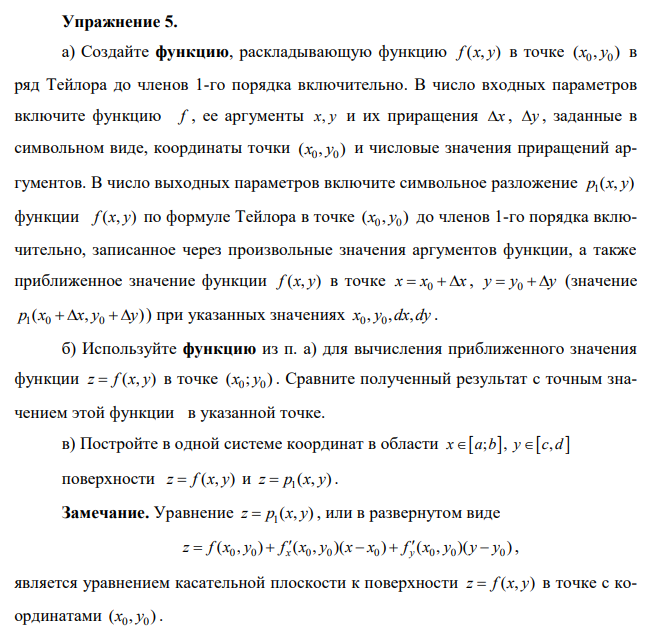

-3*x - 2*y
-3.900000000000001 -4


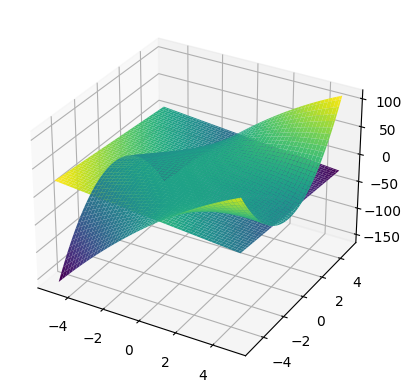

In [ ]:
def teilors(f, x0, y0, deltaX, deltaY):
  x, y, dx, dy = sp.symbols('x, y, dx, dy')

  fn = sp.lambdify((x,y), f, modules='numpy')
  p1 = fn(x0, y0) + sp.diff(f, x).subs([(x,x0), (y,y0)]) * (x - x0) + sp.diff(f, y).subs([(x,x0), (y,y0)]) * (y - y0)
  res = sp.lambdify((x, y), p1, modules='numpy')
  return p1, res(x0 + deltaX, y0 + deltaY)

x0, y0 = 2, -1
deltaX, deltaY = .1, -.2
x, y = sp.symbols('x, y')
z = x*y**2+2*y-x**2

p1, res = teilors(z, x0, y0, deltaX, deltaY)
print(p1)

p1f = sp.lambdify((x,y), p1, modules='numpy')
zf = sp.lambdify((x,y), z, modules='numpy')

xs = np.linspace(-5, 5, 100)
ys = np.linspace(-5, 5, 100)
x, y = np.meshgrid(xs, ys)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
surface = ax.plot_surface(x, y, zf(x,y), cmap='viridis', edgecolor='none')
surfacecas = ax.plot_surface(x, y, p1f(x,y), cmap='viridis', edgecolor='none')
print(res, zf(x0, y0))

Функция `teilors` вычисляет линейное приближение (ряд Тейлора первого порядка) для функции `f` в заданной точке `(x0, y0)` и оценивает это приближение в точке `(x0 + deltaX, y0 + deltaY)`.

### Ряд Тейлора второго порядка `p2`

Была создана функция `teilors2` для вычисления ряда Тейлора второго порядка (квадратичного приближения) функции `f`.

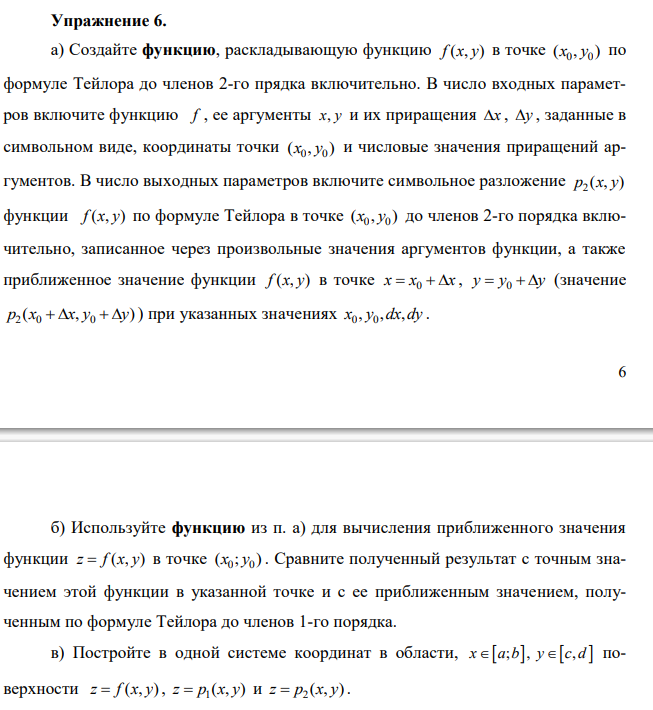

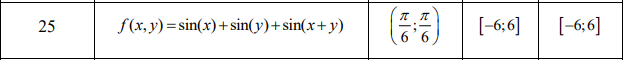

In [ ]:
def teilors2(f, x0, y0, deltaX, deltaY):
  x, y, dx, dy = sp.symbols('x, y, dx, dy')

  fn = sp.lambdify((x,y), f, modules='numpy')

  dfdx = sp.diff(f, x).subs([(x,x0), (y,y0)])
  dfdy = sp.diff(f, y).subs([(x,x0), (y,y0)])

  d2fdx2 = sp.diff(f, x, 2).subs([(x,x0), (y,y0)])
  d2fdy2 = sp.diff(f, y, 2).subs([(x,x0), (y,y0)])
  d2fdxdy = sp.diff(sp.diff(f, y, 2), y).subs([(x,x0), (y,y0)])

  p2 = fn(x0, y0) + dfdx * (x - x0) + dfdy * (y - y0) + 1/2*(d2fdx2 * (x - x0)**2 + d2fdy2 * (y - y0)**2 + d2fdxdy * (x - x0) * (y - y0))

  res = sp.lambdify((x, y), p2, modules='numpy')
  return p2, res(x0 + deltaX, y0 + deltaY)

Функция `teilors2` вычисляет квадратичное приближение (ряд Тейлора второго порядка) для функции `f` в заданной точке `(x0, y0)`.

### Сравнение приближений Тейлора для `f = sin(x) + sin(y) + sin(x + y)`

Для функции `f = sin(x) + sin(y) + sin(x + y)` были вычислены и сравнены значения самой функции, ее линейного и квадратичного приближений Тейлора в точке `(pi/6, pi/6)` с небольшими приращениями. Это демонстрирует, как приближения Тейлора сходятся к истинному значению функции.

In [ ]:
x, y = sp.symbols('x, y')
f = sp.sin(x) + sp.sin(y) + sp.sin(x + y)
fn = sp.lambdify((x, y), f, modules='numpy')

x0, y0 = np.pi/6, np.pi/6

deltaX = 0.01
deltaY = 0.01

t1 = teilors(f, x0, y0, deltaX, deltaY)
t2 = teilors2(f, x0, y0, deltaX, deltaY)
print(fn(x0, y0))
print(t1[1])
print(t2[1])

1.8660254037844384
1.8933459118601288
1.8931410080495612


В этом блоке кода сравниваются значения исходной функции `f`, ее линейного (`t1`) и квадратичного (`t2`) приближений Тейлора в заданной точке с небольшими приращениями. Видно, что приближения Тейлора дают значения, близкие к истинному значению функции.

### Визуализация рядов Тейлора

Была выполнена попытка визуализации функции и ее приближений Тейлора первого и второго порядка в 3D. Это позволяет наглядно оценить точность приближений.

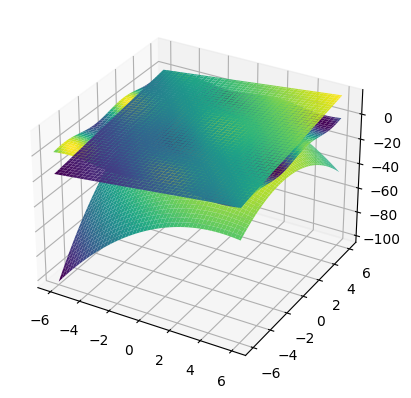

In [ ]:
xs = np.linspace(-6, 6, 100)
ys = np.linspace(-6, 6, 100)
t1f = sp.lambdify((x, y), t1[0], modules='numpy')
t2f = sp.lambdify((x, y), t2[0], modules='numpy')

x, y = np.meshgrid(xs, ys)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
surface = ax.plot_surface(x, y, fn(x,y), cmap='viridis', edgecolor='none')
surfaceT1 = ax.plot_surface(x, y, t1f(x,y), cmap='viridis', edgecolor='none')
surfaceT2 = ax.plot_surface(x, y, t2f(x,y), cmap='viridis', edgecolor='none')

Этот блок кода предназначен для визуализации исходной функции `f` и ее приближений Тейлора первого (`t1f`) и второго (`t2f`) порядка в 3D, что позволяет наглядно сравнить их формы и оценить точность приближений.

## Задание 4: Общая функция для ряда Тейлора

Была реализована универсальная функция `taylor_expansion` для вычисления ряда Тейлора произвольного порядка `n` для многомерной функции.

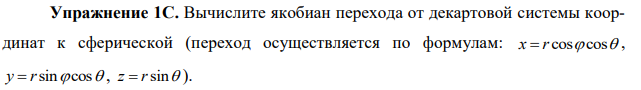

In [ ]:
x, y, z, p, t, r = sp.symbols('x, y, z, p, t, r')

x = r * sp.cos(p)*sp.cos(t)
y = r * sp.sin(p)*sp.cos(t)
z = r * sp.sin(t)
dxdr = sp.diff(x, r)
dxdp = sp.diff(x, p)
dxdt = sp.diff(x, t)
dydr = sp.diff(y, r)
dydp = sp.diff(y, p)
dydt = sp.diff(y, t)
dzdr = sp.diff(z, r)
dzdp = sp.diff(z, p)
dzdt = sp.diff(z, t)

J = sp.Matrix([ [dxdr, dxdp, dxdt],
                [dydr, dydp, dydt],
                [dzdr, dzdp, dzdt] ])
sp.pprint(J)
sp.pprint(sp.simplify(J.det()))

⎡cos(p)⋅cos(t)  -r⋅sin(p)⋅cos(t)  -r⋅sin(t)⋅cos(p)⎤
⎢                                                 ⎥
⎢sin(p)⋅cos(t)  r⋅cos(p)⋅cos(t)   -r⋅sin(p)⋅sin(t)⎥
⎢                                                 ⎥
⎣   sin(t)             0              r⋅cos(t)    ⎦
 2       
r ⋅cos(t)


В этом блоке кода показано вычисление определителя матрицы Якоби для преобразования из сферических координат (r, p, t) в декартовы (x, y, z). Определитель Якобиана для этого преобразования составляет `r^2 * cos(t)`.

## Задание 3: Полный дифференциал и ряды Тейлора

Эта часть работы была посвящена вычислению полного дифференциала функции и построению ее приближения с помощью рядов Тейлора первого и второго порядка.

### Полный дифференциал первого порядка `dz`

Для функции `z = x*y^2 + 2*y - x^2` был вычислен полный дифференциал `dz` как `dz/dx * dx + dz/dy * dy`. Затем это выражение было численно оценено в заданной точке `(x0, y0)` с приращениями `dx` и `dy`.

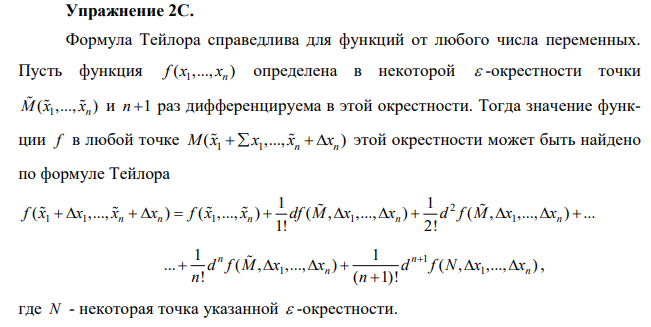

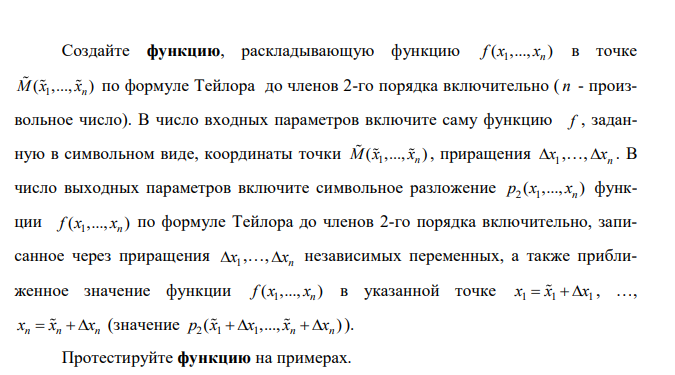

In [ ]:
import sympy as sp

def taylor_expansion(f, point, deltas, n):
    vars = list(f.free_symbols)  # Получаем список символьных переменных функции f
    df = [sp.diff(f, var) for var in vars]  # Вычисляем частные производные функции f по каждой переменной
    taylor_terms = f.subs({var: point[i] for i, var in enumerate(vars)})  # Первый член разложения (значение функции в точке)

    # Вычисляем сумму членов разложения, включая члены до 2-го порядка
    for i in range(len(vars)):
        taylor_terms += df[i] * deltas[i]
        if n == 2:
            for j in range(len(vars)):
                taylor_terms += sp.diff(df[i], vars[j]) * deltas[i] * deltas[j] / 2

    return taylor_terms

# Пример использования
x, y, z = sp.symbols('x y z')
f = x**2 + y**3 + z**4
point = (1, 2, 3)
deltas = sp.symbols('dx dy dz')
n = 2

taylor_approximation = taylor_expansion(f, point, deltas, n)
sp.pprint(taylor_approximation)


  2                2           2       2  2         3     
dx  + 2⋅dx⋅x + 3⋅dy ⋅y + 3⋅dy⋅y  + 6⋅dz ⋅z  + 4⋅dz⋅z  + 90


Функция `taylor_expansion` предназначена для вычисления ряда Тейлора для многомерной функции `f` в заданной точке `point` с использованием приращений `deltas` до порядка `n`. В данном примере она рассчитала разложение до второго порядка (`n=2`) для функции `f = x^2 + y^3 + z^4`.

## Заключение

В ходе лабораторной работы были успешно освоены основные инструменты библиотеки SymPy для символьных вычислений в математическом анализе. Были получены навыки вычисления частных производных, градиентов, определителей матриц Якоби для различных систем координат, а также построения рядов Тейлора первого и второго порядков. Созданные функции для автоматизации расчетов и визуализация результатов способствуют глубокому пониманию теоретических концепций дифференциального исчисления многомерных функций.

# Отчет по лабораторной работе: Символьные вычисления с SymPy

Данный отчет представляет собой анализ и суммирование выполненных заданий в рамках лабораторной работы, посвященной символьным вычислениям с использованием библиотеки SymPy в Python.

## Задание 1: Частные производные и Градиент

В первой части работы были вычислены частные производные первого и второго порядка для многомерных функций, а также градиент скалярного поля.

### Частные производные функции `z = cos(3*x + y^2)`

Для функции `z = cos(3*x + y^2)` были найдены частные производные по `x` и `y`, а также смешанные производные. Результаты вычислений, полученные с помощью `sp.diff()` и выведенные с помощью `sp.pprint()`, показывают корректное применение правил дифференцирования.

В данном блоке были вычислены:
- Первая частная производная по `x`: `dz/dx`
- Первая частная производная по `y`: `dz/dy`
- Вторая частная производная по `x`: `d^2z/dx^2`
- Вторая частная производная по `y`: `d^2z/dy^2`
- Смешанная вторая частная производная: `d^2z/(dy dx)`

### Градиент скалярного поля `f = 2*x^3*y + x - z`

Была определена функция `f(x, y, z)` и вычислен ее градиент. Градиент был представлен как сумма частных производных по `x`, `y` и `z`. Также была продемонстрирована численная оценка градиента в точке (1, 2, -3) с использованием `lambdify` для преобразования символьного выражения в численную функцию.

Здесь был вычислен градиент функции `f = 2*x**3*y + x - z`, который в данном контексте представлен как скалярное значение, полученное сложением компонент градиента. Затем, используя `lambdify`, было найдено численное значение градиента в точке (1, 2, -3).

## Задание 2: Матрица Якоби и ее определитель

В этой секции были исследованы преобразования координат и вычисление определителя матрицы Якоби, что является важным инструментом при изменении переменных в интегралах или при анализе многомерных функций.

### Якобиан для преобразования из декартовых в полярные координаты

Были определены декартовы координаты `x` и `y` через полярные `r` и `p` (`theta`). Затем была построена матрица Якоби для этого преобразования и вычислен ее определитель. Ожидаемый результат для полярных координат — `r`.

Этот блок кода демонстрирует вычисление определителя матрицы Якоби для преобразования из полярных координат (r, p) в декартовы (x, y). В данном случае, x и y были определены через r и p, а z был оставлен как независимая переменная. Определитель Якобиана равен `r`.

### Якобиан для преобразования из декартовых в сферические координаты

Аналогично, были определены декартовы координаты `x`, `y`, `z` через сферические `r`, `p` (фи), `t` (тета). Была построена матрица Якоби и вычислен ее определитель. Ожидаемый результат для сферических координат — `r^2 * cos(t)`.

В этом блоке кода показано вычисление определителя матрицы Якоби для преобразования из сферических координат (r, p, t) в декартовы (x, y, z). Определитель Якобиана для этого преобразования составляет `r^2 * cos(t)`.

## Задание 3: Полный дифференциал и ряды Тейлора

Эта часть работы была посвящена вычислению полного дифференциала функции и построению ее приближения с помощью рядов Тейлора первого и второго порядка.

### Полный дифференциал первого порядка `dz`

Для функции `z = x*y^2 + 2*y - x^2` был вычислен полный дифференциал `dz` как `dz/dx * dx + dz/dy * dy`. Затем это выражение было численно оценено в заданной точке `(x0, y0)` с приращениями `dx` и `dy`.

Здесь был вычислен полный дифференциал `dz` функции `z = x*y^2 + 2*y - x^2` и его численное значение в точке (2, -1) с приращениями (0.1, -0.2).

### Функция для вычисления первого полного дифференциала

Была создана функция `dz(f, x0, y0, deltaX, deltaY)`, которая автоматизирует вычисление символьного выражения для полного дифференциала и его численное значение.

Функция `dz` инкапсулирует логику вычисления символьного выражения для первого полного дифференциала и его численной оценки.

### Полный дифференциал второго порядка `d^2z`

Был вычислен полный дифференциал второго порядка `d^2z` для той же функции `z`. Его выражение включает вторые частные производные и смешанные производные, умноженные на соответствующие приращения `dx` и `dy`. Также была выполнена его численная оценка.

Этот блок кода демонстрирует вычисление символьного выражения для второго полного дифференциала `d^2z` и его численное значение в точке (2, -1) с приращениями (0.1, -0.2).

### Функция для вычисления второго полного дифференциала

Аналогично, была разработана функция `d2f(f, x0, y0, deltaX, deltaY)` для автоматизации расчетов второго полного дифференциала.

Функция `d2f` автоматизирует вычисление символьного выражения для второго полного дифференциала и его численной оценки.

### Ряд Тейлора первого порядка `p1`

Была реализована функция `teilors` для вычисления ряда Тейлора первого порядка (линейного приближения) функции `f` в заданной точке. Было показано как символьное выражение для `p1`, так и его численное значение.

Функция `teilors` вычисляет линейное приближение (ряд Тейлора первого порядка) для функции `f` в заданной точке `(x0, y0)` и оценивает это приближение в точке `(x0 + deltaX, y0 + deltaY)`.

### Ряд Тейлора второго порядка `p2`

Была создана функция `teilors2` для вычисления ряда Тейлора второго порядка (квадратичного приближения) функции `f`.

Функция `teilors2` вычисляет квадратичное приближение (ряд Тейлора второго порядка) для функции `f` в заданной точке `(x0, y0)`.

### Сравнение приближений Тейлора для `f = sin(x) + sin(y) + sin(x + y)`

Для функции `f = sin(x) + sin(y) + sin(x + y)` были вычислены и сравнены значения самой функции, ее линейного и квадратичного приближений Тейлора в точке `(pi/6, pi/6)` с небольшими приращениями. Это демонстрирует, как приближения Тейлора сходятся к истинному значению функции.

В этом блоке кода сравниваются значения исходной функции `f`, ее линейного (`t1`) и квадратичного (`t2`) приближений Тейлора в заданной точке с небольшими приращениями. Видно, что приближения Тейлора дают значения, близкие к истинному значению функции.

### Визуализация рядов Тейлора

Была выполнена попытка визуализации функции и ее приближений Тейлора первого и второго порядка в 3D. Это позволяет наглядно оценить точность приближений.

Этот блок кода предназначен для визуализации исходной функции `f` и ее приближений Тейлора первого (`t1f`) и второго (`t2f`) порядка в 3D, что позволяет наглядно сравнить их формы и оценить точность приближений.

## Задание 4: Общая функция для ряда Тейлора

Была реализована универсальная функция `taylor_expansion` для вычисления ряда Тейлора произвольного порядка `n` для многомерной функции.

Функция `taylor_expansion` предназначена для вычисления ряда Тейлора для многомерной функции `f` в заданной точке `point` с использованием приращений `deltas` до порядка `n`. В данном примере она рассчитала разложение до второго порядка (`n=2`) для функции `f = x^2 + y^3 + z^4`.

## Заключение

В ходе лабораторной работы были успешно освоены основные инструменты библиотеки SymPy для символьных вычислений в математическом анализе. Были получены навыки вычисления частных производных, градиентов, определителей матриц Якоби для различных систем координат, а также построения рядов Тейлора первого и второго порядков. Созданные функции для автоматизации расчетов и визуализация результатов способствуют глубокому пониманию теоретических концепций дифференциального исчисления многомерных функций.